#Project 10 – Clustering

Κωνσταντίνα Μαρίνα Μπλέτσα, ΑΕΜ: 243

Libraries

In [58]:
import zipfile
import pandas as pd
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics.pairwise import cosine_distances
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

Dataset

In [4]:
zip_path = "/content/dataset.csv.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/spotify_data")

df = pd.read_csv("/content/spotify_data/dataset.csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


#Ερώτημα 1

Αφαίρεση των χαρακτηριστικών (Number, Track Id, Artists, Album Name, Track Name)

In [6]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [9]:
meta_columns = [
    'Unnamed: 0',
    'track_id',
    'artists',
    'album_name',
    'track_name'
]

df_meta = df[meta_columns].copy()
df_features = df.drop(columns=meta_columns)

print("Metadata shape:", df_meta.shape)
print("Features shape:", df_features.shape)

Metadata shape: (114000, 5)
Features shape: (114000, 16)


One-Hot Encoding στα Genres

In [10]:
df_encoded = pd.get_dummies(df_features, columns=['track_genre'])

df_encoded.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,...,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,...,False,False,False,False,False,False,False,False,False,False
1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,...,False,False,False,False,False,False,False,False,False,False
2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,...,False,False,False,False,False,False,False,False,False,False
3,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,...,False,False,False,False,False,False,False,False,False,False
4,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,...,False,False,False,False,False,False,False,False,False,False


#Ερώτημα 2

Κανονικοποίηση χαρακτηριστικών με StandardScaler Z-score normalization


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

df_scaled = pd.DataFrame(
    X_scaled,
    columns=df_encoded.columns
)

df_scaled.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,...,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,1.782627,0.024575,-0.305767,0.629244,-0.717148,-1.210442,0.300828,-1.326281,0.551848,-0.850202,...,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072
1,0.975633,-0.730859,-0.305767,-0.845908,-1.889980,-1.210442,-1.784744,0.753988,-0.078993,1.831732,...,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072
2,1.065299,-0.160332,-0.305767,-0.742186,-1.122669,-1.491343,-0.293288,0.753988,-0.273826,-0.315499,...,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072
3,1.692961,-0.243214,-0.305767,-1.733304,-2.312994,-1.491343,-2.039252,0.753988,-0.457309,1.774593,...,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072
4,2.186125,-0.271919,-0.305767,0.295030,-0.788711,-0.929541,-0.282750,0.753988,-0.303145,0.463399,...,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072,-0.094072


#Ερώτημα 3

K-Means και Υπολογισμός SSE

In [16]:
k_values = [2, 3, 5, 7, 10, 15, 20]

sse = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )

    kmeans.fit(df_scaled)

    sse.append(kmeans.inertia_)

Line Plot

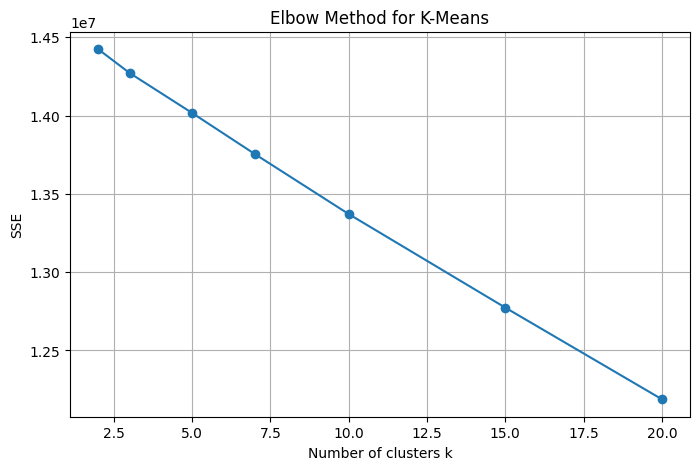

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, sse, marker='o')
plt.xlabel("Number of clusters k")
plt.ylabel("SSE")
plt.title("Elbow Method for K-Means")
plt.grid(True)
plt.show()

#Ερώτημα 4

Βέλτιστο k για Clusters και Labels

In [19]:
optimal_k = 7

kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    n_init=10,
    random_state=42
)

labels = kmeans.fit_predict(df_scaled)

labels[:10]

array([4, 4, 4, 4, 4, 4, 4, 4, 4, 4], dtype=int32)

In [22]:
df_clusters = df.copy()
df_clusters['cluster'] = labels

df_clusters.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,4
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,4
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,4
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,4
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,4


In [23]:
df_clusters['cluster'].value_counts().sort_index()

,count
cluster,
0,15369
1,25299
2,6960
3,31081
4,17802
5,3005
6,14484


#Ερώτημα 5

Ποσοστό του κυρίαρχου είδους (genre) των κομματιών σε κάθε cluster

In [25]:
dominant_genres = []

for cluster_id in sorted(df_clusters['cluster'].unique()):

    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]

    total_tracks = len(cluster_data)

    genre_counts = cluster_data['track_genre'].value_counts()

    dominant_genre = genre_counts.idxmax()
    dominant_count = genre_counts.max()

    percentage = (dominant_count / total_tracks) * 100

    dominant_genres.append({
        'cluster': cluster_id,
        'dominant_genre': dominant_genre,
        'percentage': percentage
    })

df_dominant = pd.DataFrame(dominant_genres)
df_dominant

,cluster,dominant_genre,percentage
0,0,heavy-metal,6.506604
1,1,dance,3.952725
2,2,chicago-house,14.367816
3,3,forro,3.217400
4,4,brazil,5.617346
5,5,comedy,33.277870
6,6,sleep,6.890362


Ραβδόγραμμα

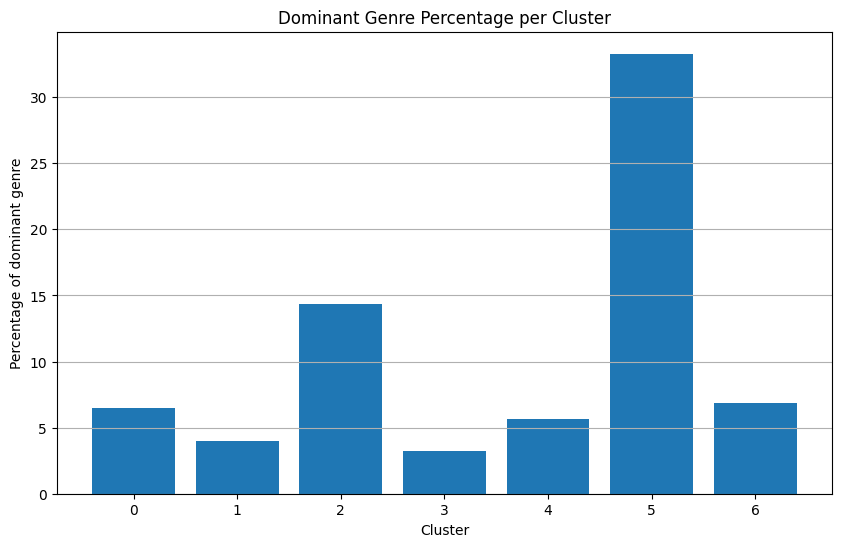

In [27]:
plt.figure(figsize=(10, 6))
plt.bar(
    df_dominant['cluster'],
    df_dominant['percentage']
)

plt.xlabel('Cluster')
plt.ylabel('Percentage of dominant genre')
plt.title('Dominant Genre Percentage per Cluster')
plt.xticks(df_dominant['cluster'])
plt.grid(axis='y')

plt.show()

#Ερώτημα 6

Πρόταση παρόμοιων τραγουδιών

In [29]:
selected_track_name = "Hold On"

selected_song = df_clusters[df_clusters['track_name'] == selected_track_name].iloc[0]
selected_song

,4
Unnamed: 0,4
track_id,5vjLSffimiIP26QG5WcN2K
artists,Chord Overstreet
album_name,Hold On
track_name,Hold On
popularity,82
duration_ms,198853
explicit,False
danceability,0.618
energy,0.443


In [30]:
selected_cluster = selected_song['cluster']

print("Τίτλος:", selected_song['track_name'])
print("Καλλιτέχνης:", selected_song['artists'])
print("Cluster:", selected_cluster)

Τίτλος: Hold On
Καλλιτέχνης: Chord Overstreet
Cluster: 4


In [31]:
cluster_songs = df_clusters[df_clusters['cluster'] == selected_cluster]

In [32]:
song_index = selected_song.name

song_vector = df_scaled.loc[song_index].values.reshape(1, -1)

cluster_indices = cluster_songs.index
cluster_vectors = df_scaled.loc[cluster_indices]

distances = euclidean_distances(song_vector, cluster_vectors)[0]

In [33]:
recommendations = cluster_songs.copy()
recommendations['distance'] = distances

recommendations = recommendations[recommendations.index != song_index]

top3 = recommendations.sort_values('distance').head(3)
top3[['track_name', 'artists', 'distance']]

,track_name,artists,distance
588,Green Mountain State,Trevor Hall,1.549837
322,Binibini (Last Day On Earth) (feat. James TW),Zack Tabudlo;James TW,1.702699
75,93 Million Miles,Jason Mraz,1.724058


Τα 3 προτεινόμενα τραγούδια είναι παρόμοια σε μουσικό ύφος με το «Hold On» ειναι Acoustic / Pop και "συναισθηματικά"

#Ερώτημα 7

Επανάληψη του ερωτήματος 6 με Cosine Distance ως μετρική απόστασης

In [35]:
selected_track_name = "Hold On"

selected_song = df_clusters[df_clusters['track_name'] == selected_track_name].iloc[0]
selected_cluster = selected_song['cluster']

In [36]:
cluster_songs = df_clusters[df_clusters['cluster'] == selected_cluster]

song_index = selected_song.name

song_vector = df_scaled.loc[song_index].values.reshape(1, -1)

cluster_indices = cluster_songs.index
cluster_vectors = df_scaled.loc[cluster_indices]

In [37]:
cosine_dist = cosine_distances(song_vector, cluster_vectors)[0]

In [38]:
recommendations_cosine = cluster_songs.copy()
recommendations_cosine['cosine_distance'] = cosine_dist

recommendations_cosine = recommendations_cosine[
    recommendations_cosine.index != song_index
]

top3_cosine = recommendations_cosine.sort_values('cosine_distance').head(3)
top3_cosine[['track_name', 'artists', 'cosine_distance']]

,track_name,artists,cosine_distance
588,Green Mountain State,Trevor Hall,0.009754
322,Binibini (Last Day On Earth) (feat. James TW),Zack Tabudlo;James TW,0.011783
75,93 Million Miles,Jason Mraz,0.012084


Συγκρίνοντας τις δύο μετρικές απόστασης, βλέπω ότι η Cosine Distance έχει πιο ακριβή μέτρηση ομοιότητας, και οι αποστάσεις είναι πολύ μικρότερες, οι προτεινόμενες επιλογές τραγουδιών είναι ίδιες και στις δύο περιπτώσεις

#Ερώτημα 8

Ερωτήματα 4 με 7 K-Means με k = 5

In [52]:
k_elbow = 5

kmeans_5 = KMeans(
    n_clusters=k_elbow,
    init='k-means++',
    n_init=10,
    random_state=42
)

labels_5 = kmeans_5.fit_predict(df_scaled)

df_clusters_5 = df.copy()
df_clusters_5['cluster'] = labels_5

In [53]:
df_clusters_5['cluster'].value_counts().sort_index()

,count
cluster,
0,4030
1,39733
2,31560
3,28015
4,10662


In [54]:
dominant_genres_5 = []

for cluster_id in sorted(df_clusters_5['cluster'].unique()):
    cluster_data = df_clusters_5[df_clusters_5['cluster'] == cluster_id]
    total_tracks = len(cluster_data)
    genre_counts = cluster_data['track_genre'].value_counts()

    dominant_genres_5.append({
        'cluster': cluster_id,
        'dominant_genre': genre_counts.idxmax(),
        'percentage': (genre_counts.max() / total_tracks) * 100
    })

df_dominant_5 = pd.DataFrame(dominant_genres_5)
df_dominant_5

,cluster,dominant_genre,percentage
0,0,dancehall,24.813896
1,1,breakbeat,2.516800
2,2,cantopop,3.168568
3,3,forro,3.569516
4,4,sleep,9.369724


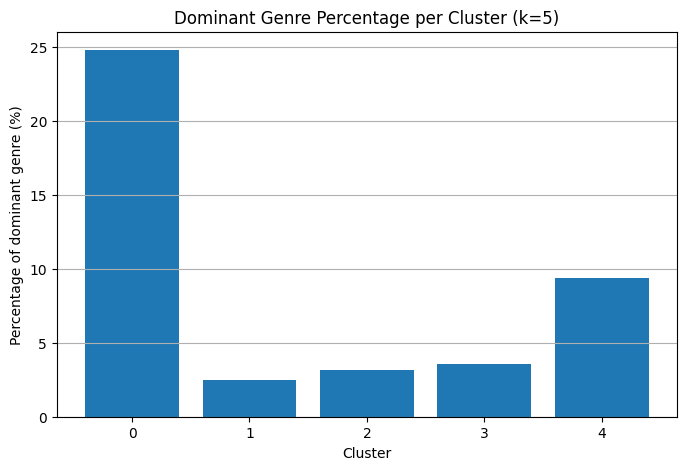

In [55]:
plt.figure(figsize=(8,5))
plt.bar(df_dominant_5['cluster'], df_dominant_5['percentage'])
plt.xlabel('Cluster')
plt.ylabel('Percentage of dominant genre (%)')
plt.title('Dominant Genre Percentage per Cluster (k=5)')
plt.grid(axis='y')
plt.show()

Recommendation με Ευκλείδεια απόσταση

In [56]:
selected_song_5 = df_clusters_5[
    df_clusters_5['track_name'] == "Hold On"
].iloc[0]

cluster_5 = selected_song_5['cluster']
cluster_songs_5 = df_clusters_5[df_clusters_5['cluster'] == cluster_5]

song_index_5 = selected_song_5.name
song_vector_5 = df_scaled.loc[song_index_5].values.reshape(1, -1)
cluster_vectors_5 = df_scaled.loc[cluster_songs_5.index]

distances_5 = euclidean_distances(song_vector_5, cluster_vectors_5)[0]

recommendations_5 = cluster_songs_5.copy()
recommendations_5['distance'] = distances_5
recommendations_5 = recommendations_5[recommendations_5.index != song_index_5]

top3_euclidean_5 = recommendations_5.sort_values('distance').head(3)
top3_euclidean_5[['track_name', 'artists', 'distance']]

,track_name,artists,distance
588,Green Mountain State,Trevor Hall,1.549837
322,Binibini (Last Day On Earth) (feat. James TW),Zack Tabudlo;James TW,1.702699
75,93 Million Miles,Jason Mraz,1.724058


Recommendation με Cosine Distance

In [57]:
cluster_songs_5_no_self = cluster_songs_5[
    cluster_songs_5.index != song_index_5
]

cluster_vectors_5_no_self = df_scaled.loc[cluster_songs_5_no_self.index]

cosine_dist_5 = cosine_distances(
    song_vector_5,
    cluster_vectors_5_no_self
)[0]

recommendations_5 = cluster_songs_5_no_self.copy()
recommendations_5['cosine_distance'] = cosine_dist_5

top3_cosine_5 = recommendations_5.sort_values('cosine_distance').head(3)
top3_cosine_5[['track_name', 'artists', 'cosine_distance']]

,track_name,artists,cosine_distance
588,Green Mountain State,Trevor Hall,0.009754
322,Binibini (Last Day On Earth) (feat. James TW),Zack Tabudlo;James TW,0.011783
75,93 Million Miles,Jason Mraz,0.012084


#Ερώτημα 9

DBSCAN

In [59]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(df_scaled)

In [60]:
unique_labels = set(dbscan_labels)
n_clusters_dbscan = len(unique_labels) - (1 if -1 in unique_labels else 0)

n_clusters_dbscan

553

In [61]:
noise_points = np.sum(dbscan_labels == -1)
noise_points

np.int64(69939)

In [63]:
df_dbscan = df.copy()
df_dbscan['cluster'] = dbscan_labels

Επιλογή τραγουδιού

In [64]:
selected_track_name = "Hold On"

selected_song_db = df_dbscan[
    df_dbscan['track_name'] == selected_track_name
].iloc[0]

selected_cluster_db = selected_song_db['cluster']

print("Τίτλος:", selected_song_db['track_name'])
print("Καλλιτέχνης:", selected_song_db['artists'])
print("DBSCAN cluster:", selected_cluster_db)

Τίτλος: Hold On
Καλλιτέχνης: Chord Overstreet
DBSCAN cluster: -1


Θόρυβος

In [66]:
if selected_cluster_db == -1:
    print("Το τραγούδι χαρακτηρίζεται ως θόρυβος από τον DBSCAN")
else:
    print("Το τραγούδι ανήκει σε DBSCAN cluster")

Το τραγούδι χαρακτηρίζεται ως θόρυβος από τον DBSCAN


Recommendation με Ευκλείδεια απόσταση (DBSCAN – noise case)

In [67]:
song_index = selected_song_db.name
song_vector = df_scaled.loc[song_index].values.reshape(1, -1)

non_noise = df_dbscan[df_dbscan['cluster'] != -1]

non_noise_vectors = df_scaled.loc[non_noise.index]

distances = euclidean_distances(song_vector, non_noise_vectors)[0]

recommendations_db = non_noise.copy()
recommendations_db['distance'] = distances

top3_db_euclidean = recommendations_db.sort_values('distance').head(3)

top3_db_euclidean[['track_name', 'artists', 'distance']]

,track_name,artists,distance
588,Green Mountain State,Trevor Hall,1.549837
322,Binibini (Last Day On Earth) (feat. James TW),Zack Tabudlo;James TW,1.702699
75,93 Million Miles,Jason Mraz,1.724058


Recommendation με Cosine Distance (DBSCAN – noise case)

In [68]:
cos_dist = cosine_distances(song_vector, non_noise_vectors)[0]

recommendations_db['cosine_distance'] = cos_dist

top3_db_cosine = recommendations_db.sort_values('cosine_distance').head(3)

top3_db_cosine[['track_name', 'artists', 'cosine_distance']]

,track_name,artists,cosine_distance
588,Green Mountain State,Trevor Hall,0.009754
322,Binibini (Last Day On Earth) (feat. James TW),Zack Tabudlo;James TW,0.011783
75,93 Million Miles,Jason Mraz,0.012084


Συγκρίνοντας τους παρατηρώ ότι ο K-Means παράγει μικρό αριθμό clusters (k = 7 στο Ερώτημα 4 και k = 5 στο Ερώτημα 8), ενώ ο DBSCAN εντοπίζει πολύ μεγαλύτερο αριθμό clusters (553) και χαρακτηρίζει μεγάλο ποσοστό των δεδομένων ως θόρυβο. Η διαφορά τους οφείλεται στο οτι ο K-Means ομαδοποιεί βάσει απόστασης από κέντρα, ενώ ο DBSCAN βασίζεται στην πυκνότητα των δεδομένων.